<a href="https://www.kaggle.com/code/myassine00/notebook29ebe4080c?scriptVersionId=333967460" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# GEFF Graph Data — Loading & Analysis

This notebook loads a **GEFF** (`.geff`) graph folder stored as a `zarr` store, reconstructs the
underlying graph, and runs exploratory data analysis (EDA), feature engineering, and graph
analytics on it.

A `.geff` folder contains:
```
my_graph.geff/
├── nodes/
├── edges/
└── zarr.json
```

The notebook is organized into the following sections:

1. Load Libraries
2. Load Data
3. Inspect GEFF/Zarr Structure
4. Extract Nodes and Edges
5. Load Node and Edge Properties
6. Convert to NetworkX Graph
7. Basic EDA
8. Graph EDA
9. Feature Engineering
10. Save Processed Data
11. Domain-Specific Tracking Features (physical units, motion, divisions)
12. Multi-Sample / Embryo-Aware Dataset Summary

**Competition-specific notes baked into this notebook:**
- Each sample is a paired `{embryo_id}_{field_of_view}.zarr` (image, shape `(T, Z, Y, X)`) +
  `.geff` (ground-truth graph). Section 2 builds a manifest pairing them automatically.
- Node properties are named exactly `t, z, y, x` (voxel coordinates); Section 11 converts
  these to microns using the voxel scale `z=1.625, y=0.40625, x=0.40625 µm/voxel`.
- Annotations are **sparse** — `estimated_number_of_nodes` (in the `.geff` metadata) is the
  true estimated cell count, which can be much larger than `len(nodes/ids)`. This notebook
  surfaces that gap explicitly rather than treating labeled counts as ground truth totals.
- Train/test are **embryo-disjoint**. Section 12 aggregates by `embryo_id` so any local
  validation split can respect that boundary.

## 1. Load Libraries

In [1]:
!pip -q install zarr pandas numpy networkx matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 83.8 MB/s eta 0:00:00


In [2]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import zarr
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

print("Libraries loaded successfully.")
print(f"zarr version: {zarr.__version__}")
print(f"networkx version: {nx.__version__}")
print(f"pandas version: {pd.__version__}")

Libraries loaded successfully.
zarr version: 3.2.1
networkx version: 3.6.1
pandas version: 2.3.3


## 2. Load Data

Automatically search `/kaggle/input` for any `.geff` folders and select the first one found.

Each competition sample is a **paired** `{embryo_id}_{field_of_view}.zarr` (image volume) +
`{embryo_id}_{field_of_view}.geff` (ground-truth tracking graph). We build a manifest of all
such pairs (matching by stem name in the same parent folder), parse out `embryo_id` /
`field_of_view`, and default to the first `.geff` for the deep-dive sections below. This
manifest is reused in Section 11 for the multi-sample / embryo-aware analysis.

In [3]:
# Physical voxel scale (µm/voxel), as given in the dataset description
VOXEL_SCALE = {"z": 1.625, "y": 0.40625, "x": 0.40625}

INPUT_ROOT = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")

geff_paths = sorted(INPUT_ROOT.rglob("*.geff"))

print(f"Found {len(geff_paths)} .geff folder(s).")

if len(geff_paths) == 0:
    raise FileNotFoundError(
        "No .geff folders found under /kaggle/input. "
        "Please attach a dataset that contains a .geff folder."
    )

# Build a manifest pairing each .geff with its sibling .zarr (same stem, same parent folder)
manifest_rows = []
for geff_path in geff_paths:
    stem = geff_path.stem  # e.g. "44b6_0049_0438_1330_1273"
    zarr_path = geff_path.parent / f"{stem}.zarr"
    parts = stem.split("_")
    embryo_id = parts[0] if len(parts) > 0 else None

    manifest_rows.append({
        "sample_id": stem,
        "embryo_id": embryo_id,
        "geff_path": geff_path,
        "zarr_path": zarr_path if zarr_path.exists() else None,
        "has_paired_zarr": zarr_path.exists(),
    })

samples_manifest = pd.DataFrame(manifest_rows)
print(f"\nBuilt manifest of {len(samples_manifest)} sample(s), "
      f"{samples_manifest['embryo_id'].nunique()} unique embryo_id(s).")
print(f"Samples with a paired .zarr found: {samples_manifest['has_paired_zarr'].sum()} / {len(samples_manifest)}")
display(samples_manifest.head())

# Select the first .geff (and its paired .zarr, if present) by default for the deep-dive below
GEFF_PATH = geff_paths[0]
ZARR_PATH = samples_manifest.loc[0, "zarr_path"]
print(f"\nUsing GEFF folder: {GEFF_PATH}")
print(f"Paired ZARR volume: {ZARR_PATH if ZARR_PATH is not None else '[not found]'}")

Found 199 .geff folder(s).

Built manifest of 199 sample(s), 2 unique embryo_id(s).
Samples with a paired .zarr found: 199 / 199


,sample_id,embryo_id,geff_path,zarr_path,has_paired_zarr
0,44b6_0113de3b,44b6,/kaggle/input/competitions/biohub-cell-trackin...,/kaggle/input/competitions/biohub-cell-trackin...,True
1,44b6_0b24845f,44b6,/kaggle/input/competitions/biohub-cell-trackin...,/kaggle/input/competitions/biohub-cell-trackin...,True
2,44b6_0c582fdc,44b6,/kaggle/input/competitions/biohub-cell-trackin...,/kaggle/input/competitions/biohub-cell-trackin...,True
3,44b6_0db75fae,44b6,/kaggle/input/competitions/biohub-cell-trackin...,/kaggle/input/competitions/biohub-cell-trackin...,True
4,44b6_12dfb391,44b6,/kaggle/input/competitions/biohub-cell-trackin...,/kaggle/input/competitions/biohub-cell-trackin...,True



Using GEFF folder: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.geff
Paired ZARR volume: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.zarr


## 3. Inspect GEFF/Zarr Structure

Open the `.geff` folder as a zarr store and print its hierarchy (`nodes/`, `edges/`, sub-arrays,
and any metadata in `zarr.json` / group attrs).

In [ ]:
print(f"Opening zarr store at: {GEFF_PATH}\n")
root = zarr.open(str(GEFF_PATH), mode="r")


def safe_get_array(group, path):
    """Safely fetch an array/group from a zarr group by a slash-separated path.
    Returns None instead of raising if any part of the path is missing."""
    parts = path.split("/")
    current = group
    for part in parts:
        try:
            current = current[part]
        except Exception:
            return None
    return current


def print_zarr_tree(group, prefix=""):
    """Recursively print the structure of a zarr group (defensive: never crashes)."""
    try:
        keys = list(group.keys())
    except Exception as e:
        print(f"{prefix}[Could not list keys: {e}]")
        return

    for key in keys:
        try:
            item = group[key]
        except Exception as e:
            print(f"{prefix}{key}  [could not open: {e}]")
            continue

        if isinstance(item, zarr.Group):
            print(f"{prefix}{key}/  (group)")
            print_zarr_tree(item, prefix=prefix + "    ")
        else:
            print(f"{prefix}{key}  shape={item.shape} dtype={item.dtype}")


print("GEFF/Zarr structure:")
print_zarr_tree(root)


def get_estimated_number_of_nodes(attrs):
    """Return the nested GEFF estimated node count, or None if unavailable or invalid."""
    try:
        value = (
            attrs
            .get("geff", {})
            .get("extra", {})
            .get("estimated_number_of_nodes")
        )
    except AttributeError:
        return None

    if value is None:
        return None

    try:
        return int(value)
    except (TypeError, ValueError):
        return None

# Attempt to load top-level zarr.json metadata if present
zarr_json_path = GEFF_PATH / "zarr.json"
if zarr_json_path.exists():
    print("\nzarr.json contents:")
    try:
        with open(zarr_json_path, "r") as f:
            zarr_meta = json.load(f)
        print(json.dumps(zarr_meta, indent=2, default=str))
    except Exception as e:
        print(f"Could not parse zarr.json: {e}")
else:
    print("\nNo top-level zarr.json file found (may be nested, or a different zarr layout).")

# Also print root group attrs, if any
try:
    root_attrs = dict(root.attrs)
    if len(root_attrs) > 0:
        print("\nRoot group attrs:")
        print(json.dumps(root_attrs, indent=2, default=str))
    else:
        print("\nNo root-level attrs found.")
except Exception as e:
    print(f"Could not read root attrs: {e}")

# Annotations are sparse -- estimated_number_of_nodes (in the .geff metadata) is the
# organizers' estimate of the TRUE total cell count, which can be much larger than
# len(nodes/ids). Surface it clearly so it isn't mistaken for the real count.
estimated_number_of_nodes = get_estimated_number_of_nodes(root_attrs)

if estimated_number_of_nodes is not None:
    print(f"\nestimated_number_of_nodes (from .geff metadata): {estimated_number_of_nodes}")
else:
    print("\n'estimated_number_of_nodes' not found in root attrs -- will check again after loading nodes/ids.")

Opening zarr store at: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.geff

GEFF/Zarr structure:
edges/  (group)
    ids  shape=(50, 2) dtype=uint64
    props/  (group)
nodes/  (group)
    ids  shape=(52,) dtype=uint64
    props/  (group)
        x/  (group)
            values  shape=(52,) dtype=int64
        y/  (group)
            values  shape=(52,) dtype=int64
        z/  (group)
            values  shape=(52,) dtype=int64
        t/  (group)
            values  shape=(52,) dtype=int64

zarr.json contents:
{
  "attributes": {
    "geff": {
      "geff_version": "1.1",
      "directed": true,
      "axes": [
        {
          "name": "t",
          "type": "time",
          "unit": null,
          "min": 0.0,
          "max": 75.0,
          "scale": 1.0,
          "scaled_unit": null,
          "offset": null
        },
        {
          "name": "z",
          "type": "space",
          "unit": null,
          "min": 1.0,
          "max":

### 3.1 Inspect the paired `.zarr` image volume

Each sample also has an image volume at `{sample}.zarr`, with a single array at `0/`
of shape `(T, Z, Y, X)` (typically `(100, 64, 256, 256)`, `uint16`), chunked one timepoint
at a time. We inspect its metadata the same defensive way.

In [5]:
if ZARR_PATH is not None:
    print(f"Opening image volume zarr store at: {ZARR_PATH}\n")
    image_root = zarr.open(str(ZARR_PATH), mode="r")

    print("Image volume zarr structure:")
    print_zarr_tree(image_root)

    image_arr = safe_get_array(image_root, "0")
    if image_arr is not None:
        print(f"\nImage array '0/': shape={image_arr.shape}, dtype={image_arr.dtype}")
        T, Z, Y, X = image_arr.shape if len(image_arr.shape) == 4 else (None, None, None, None)
        if T is not None:
            print(f"  -> T={T} timepoints, Z={Z}, Y={Y}, X={X}")
            print(f"  -> physical volume size: "
                  f"{Z * VOXEL_SCALE['z']:.1f} x {Y * VOXEL_SCALE['y']:.1f} x {X * VOXEL_SCALE['x']:.1f} µm (Z x Y x X)")
    else:
        print("\nCould not find the image array at path '0/' in this zarr store.")
else:
    print("No paired .zarr volume found for this sample -- skipping image volume inspection.")
    image_root = None
    image_arr = None

Opening image volume zarr store at: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_0113de3b.zarr

Image volume zarr structure:
0  shape=(100, 64, 256, 256) dtype=uint16

Image array '0/': shape=(100, 64, 256, 256), dtype=uint16
  -> T=100 timepoints, Z=64, Y=256, X=256
  -> physical volume size: 104.0 x 104.0 x 104.0 µm (Z x Y x X)


## 4. Extract Nodes and Edges

Extract `nodes/ids` and `edges/ids`, building `nodes_df` and `edges_df`
(`source`, `target`). If edge ids are shaped `(2, n_edges)` they are transposed to
`(n_edges, 2)`.

In [ ]:
def safe_get_array(group, path):
    """Safely fetch an array/group from a zarr group by a slash-separated path.
    Returns None instead of raising if any part of the path is missing."""
    parts = path.split("/")
    current = group
    for part in parts:
        try:
            current = current[part]
        except Exception:
            return None
    return current


# --- Nodes ---
node_ids_arr = safe_get_array(root, "nodes/ids")
if node_ids_arr is None:
    raise KeyError("Could not find 'nodes/ids' in the GEFF store.")

node_ids = np.asarray(node_ids_arr)
print(f"nodes/ids shape: {node_ids.shape}, dtype: {node_ids.dtype}")

nodes_df = pd.DataFrame({"node_id": node_ids.ravel()})
print("\nInitial nodes_df:")
display(nodes_df.head())

# Annotations are sparse: compare the labeled node count against estimated_number_of_nodes
n_labeled_nodes = len(nodes_df)
print(f"\nLabeled nodes in this sample: {n_labeled_nodes}")
if estimated_number_of_nodes is not None:
    coverage = (
        n_labeled_nodes / estimated_number_of_nodes
        if estimated_number_of_nodes > 0
        else np.nan
    )
    print(f"Estimated true cell count: {estimated_number_of_nodes}")
    print(f"Approximate annotation coverage: {coverage:.1%}")
else:
    print("No estimated_number_of_nodes available for this sample -- cannot estimate coverage.")

# --- Edges ---
edge_ids_arr = safe_get_array(root, "edges/ids")
if edge_ids_arr is None:
    raise KeyError("Could not find 'edges/ids' in the GEFF store.")

edge_ids = np.asarray(edge_ids_arr)
print(f"\nedges/ids shape: {edge_ids.shape}, dtype: {edge_ids.dtype}")

# Handle shape (2, n_edges) vs (n_edges, 2)
if edge_ids.ndim == 2 and edge_ids.shape[0] == 2 and edge_ids.shape[1] != 2:
    print("Detected edges/ids shape (2, n_edges) -> transposing to (n_edges, 2).")
    edge_ids = edge_ids.T
elif edge_ids.ndim == 2 and edge_ids.shape[1] == 2:
    print("edges/ids already shaped (n_edges, 2).")
else:
    raise ValueError(f"Unexpected edges/ids shape: {edge_ids.shape}")

edges_df = pd.DataFrame(edge_ids, columns=["source", "target"])
print("\nInitial edges_df:")
display(edges_df.head())

nodes/ids shape: (52,), dtype: uint64

Initial nodes_df:


,node_id
0,11000000075
1,12000000075
2,13000000075
3,38000000003
4,39000000003



Labeled nodes in this sample: 52
No estimated_number_of_nodes available for this sample -- cannot estimate coverage.

edges/ids shape: (50, 2), dtype: uint64
edges/ids already shaped (n_edges, 2).

Initial edges_df:


,source,target
0,11000000075,12000000075
1,12000000075,13000000075
2,38000000003,39000000003
3,39000000003,40000000003
4,40000000003,41000000003


## 5. Load Node and Edge Properties

Load every property found under `nodes/props/*/values` and `edges/props/*/values`.
Multi-dimensional properties are split into separate columns (`propname_0`, `propname_1`, ...).
This step is fully defensive: it never crashes if properties are missing, malformed, or
misaligned with the number of nodes/edges.

In [7]:
def load_props(root_group, props_path, id_count, label):
    """
    Load all properties under `<props_path>/<prop_name>/values` into a dict of columns.
    - Skips gracefully if the props group doesn't exist or is empty.
    - Skips a property if its first dimension doesn't match id_count (avoids misalignment).
    - Splits multi-dimensional properties into separate flat columns.
    """
    props_dict = {}
    props_group = safe_get_array(root_group, props_path)

    if props_group is None:
        print(f"No '{props_path}' group found -- skipping {label} properties.")
        return props_dict

    try:
        prop_names = list(props_group.keys())
    except Exception as e:
        print(f"Could not list {label} properties under '{props_path}': {e}")
        return props_dict

    if len(prop_names) == 0:
        print(f"'{props_path}' exists but contains no properties.")
        return props_dict

    print(f"Found {len(prop_names)} {label} propert(y/ies): {prop_names}")

    for prop_name in prop_names:
        prop_group = safe_get_array(props_group, prop_name)
        if prop_group is None:
            print(f"  - '{prop_name}' could not be opened -- skipping.")
            continue

        values = safe_get_array(prop_group, "values")
        if values is None:
            print(f"  - '{prop_name}' has no 'values' array -- skipping.")
            continue

        try:
            values = np.asarray(values)
        except Exception as e:
            print(f"  - '{prop_name}' could not be converted to an array ({e}) -- skipping.")
            continue

        if values.shape[0] != id_count:
            print(
                f"  - WARNING: '{prop_name}' first-dim length ({values.shape[0]}) "
                f"!= number of {label} ids ({id_count}). Skipping to avoid misalignment."
            )
            continue

        if values.ndim == 1:
            props_dict[prop_name] = values
            print(f"  - Loaded '{prop_name}' as a single column (shape {values.shape}).")
        else:
            n_cols = int(np.prod(values.shape[1:]))
            flat_values = values.reshape(values.shape[0], n_cols)
            for i in range(n_cols):
                col_name = f"{prop_name}_{i}"
                props_dict[col_name] = flat_values[:, i]
            print(f"  - Loaded '{prop_name}' as {n_cols} column(s) (original shape {values.shape}).")

    return props_dict


print("Loading node properties...")
node_props = load_props(root, "nodes/props", node_ids.shape[0], "node")

print("\nLoading edge properties...")
edge_props = load_props(root, "edges/props", edge_ids.shape[0], "edge")

# Merge properties into the dataframes
for col, values in node_props.items():
    nodes_df[col] = values

for col, values in edge_props.items():
    edges_df[col] = values

print("\nnodes_df with properties:")
display(nodes_df.head())

print("\nedges_df with properties:")
display(edges_df.head())

Loading node properties...
Found 4 node propert(y/ies): ['z', 'x', 'y', 't']
  - Loaded 'z' as a single column (shape (52,)).
  - Loaded 'x' as a single column (shape (52,)).
  - Loaded 'y' as a single column (shape (52,)).
  - Loaded 't' as a single column (shape (52,)).

Loading edge properties...
'edges/props' exists but contains no properties.

nodes_df with properties:


,node_id,z,x,y,t
0,11000000075,63,249,222,0
1,12000000075,63,251,227,1
2,13000000075,63,253,230,2
3,38000000003,1,73,74,27
4,39000000003,3,75,78,28



edges_df with properties:


,source,target
0,11000000075,12000000075
1,12000000075,13000000075
2,38000000003,39000000003
3,39000000003,40000000003
4,40000000003,41000000003


## 6. Convert to NetworkX Graph

Build a directed `networkx` graph from `edges_df`. To avoid
`NetworkXError: Invalid edge_attr argument`, `edge_attr` is only passed when `edges_df`
actually has columns beyond `source`/`target`. Node properties are attached afterwards, and any
node that appears in `nodes_df` but not in `edges_df` (isolated node) is still added to the graph.

In [8]:
extra_edge_cols = [c for c in edges_df.columns if c not in ("source", "target")]
print(f"Extra edge attribute columns: {extra_edge_cols if extra_edge_cols else 'None'}")

# Build the graph from edges, only using edge_attr if extra columns exist
if len(extra_edge_cols) > 0:
    G = nx.from_pandas_edgelist(
        edges_df,
        source="source",
        target="target",
        edge_attr=extra_edge_cols,
        create_using=nx.DiGraph(),
    )
else:
    G = nx.from_pandas_edgelist(
        edges_df,
        source="source",
        target="target",
        create_using=nx.DiGraph(),
    )

# Attach node properties, and make sure every node in nodes_df is present
# (this also adds isolated nodes that have no edges at all).
node_attr_cols = [c for c in nodes_df.columns if c != "node_id"]

for _, row in nodes_df.iterrows():
    nid = row["node_id"]
    if nid not in G:
        G.add_node(nid)
    if node_attr_cols:
        attrs = {col: row[col] for col in node_attr_cols}
        G.nodes[nid].update(attrs)

print(f"\nGraph created: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")
print(f"Directed: {G.is_directed()}")

Extra edge attribute columns: None

Graph created: 52 nodes, 50 edges.
Directed: True


## 7. Basic EDA

### 7.1 `nodes_df` EDA

In [9]:
print("=" * 60)
print("NODES_DF - Basic EDA")
print("=" * 60)

print(f"\nShape: {nodes_df.shape}")

print("\nHead:")
display(nodes_df.head())

print("\nMissing values per column:")
display(nodes_df.isnull().sum())

print("\nDtypes:")
display(nodes_df.dtypes)

numeric_nodes_df = nodes_df.select_dtypes(include=[np.number])
if numeric_nodes_df.shape[1] > 0:
    print("\nNumeric summary:")
    display(numeric_nodes_df.describe())
else:
    print("\nNo numeric columns found in nodes_df to summarize.")

n_dup_nodes = nodes_df["node_id"].duplicated().sum()
print(f"\nDuplicate node IDs: {n_dup_nodes}")

n_unique_nodes = nodes_df["node_id"].nunique()
print(f"Unique node IDs: {n_unique_nodes} (out of {len(nodes_df)} rows)")

NODES_DF - Basic EDA

Shape: (52, 5)

Head:


,node_id,z,x,y,t
0,11000000075,63,249,222,0
1,12000000075,63,251,227,1
2,13000000075,63,253,230,2
3,38000000003,1,73,74,27
4,39000000003,3,75,78,28



Missing values per column:


node_id    0
z          0
x          0
y          0
t          0
dtype: int64


Dtypes:


node_id    uint64
z           int64
x           int64
y           int64
t           int64
dtype: object


Numeric summary:


,node_id,z,x,y,t
count,5.200000e+01,52.000000,52.000000,52.000000,52.000000
mean,5.911538e+10,36.057692,133.096154,123.500000,48.115385
std,1.818710e+10,19.437596,49.416303,29.072931,18.187104
min,1.100000e+10,1.000000,73.000000,74.000000,0.000000
25%,4.775000e+10,18.750000,91.250000,114.000000,36.750000
50%,6.050000e+10,37.500000,125.000000,122.500000,49.500000
75%,7.325000e+10,53.250000,165.750000,127.000000,62.250000
max,8.600000e+10,63.000000,253.000000,230.000000,75.000000



Duplicate node IDs: 0
Unique node IDs: 52 (out of 52 rows)


### 7.2 `edges_df` EDA

In [10]:
print("=" * 60)
print("EDGES_DF - Basic EDA")
print("=" * 60)

print(f"\nShape: {edges_df.shape}")

print("\nHead:")
display(edges_df.head())

print("\nMissing values per column:")
display(edges_df.isnull().sum())

n_dup_edges = edges_df.duplicated(subset=["source", "target"]).sum()
print(f"\nDuplicate edges (same source/target pair): {n_dup_edges}")

n_self_loops = int((edges_df["source"] == edges_df["target"]).sum())
print(f"Self-loops: {n_self_loops}")

n_unique_sources = edges_df["source"].nunique()
n_unique_targets = edges_df["target"].nunique()
print(f"Unique source nodes: {n_unique_sources}")
print(f"Unique target nodes: {n_unique_targets}")

EDGES_DF - Basic EDA

Shape: (50, 2)

Head:


,source,target
0,11000000075,12000000075
1,12000000075,13000000075
2,38000000003,39000000003
3,39000000003,40000000003
4,40000000003,41000000003



Missing values per column:


source    0
target    0
dtype: int64


Duplicate edges (same source/target pair): 0
Self-loops: 0
Unique source nodes: 50
Unique target nodes: 50


## 8. Graph EDA

Structural analysis of the `networkx` graph: size, connectivity, degree distribution,
density, and tree/forest/cycle checks. Every computation here is wrapped defensively so a
disconnected or unusual graph never crashes the notebook.

In [11]:
print("=" * 60)
print("NETWORKX GRAPH - EDA")
print("=" * 60)

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
is_directed = G.is_directed()

print(f"\nNumber of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Directed: {is_directed}")

# Connected components -- use weakly connected components for directed graphs
if is_directed:
    components = list(nx.weakly_connected_components(G))
    print("\n(Using WEAKLY connected components since the graph is directed.)")
else:
    components = list(nx.connected_components(G))

n_components = len(components)
component_sizes = sorted([len(c) for c in components], reverse=True)

print(f"Number of connected components: {n_components}")
print(f"Top 10 component sizes: {component_sizes[:10]}")

isolated_nodes = list(nx.isolates(G))
print(f"\nIsolated nodes: {len(isolated_nodes)}")

# Degree distribution
degrees = [d for _, d in G.degree()]
avg_degree = float(np.mean(degrees)) if len(degrees) > 0 else 0.0
print(f"\nAverage degree: {avg_degree:.4f}")

density = nx.density(G)
print(f"Graph density: {density:.6f}")

# Tree / forest checks (defined on the undirected version, defensive against errors)
G_undirected = G.to_undirected() if is_directed else G

try:
    is_tree = nx.is_tree(G_undirected)
except Exception as e:
    print(f"Could not evaluate is_tree: {e}")
    is_tree = False

try:
    is_forest = nx.is_forest(G_undirected)
except Exception as e:
    print(f"Could not evaluate is_forest: {e}")
    is_forest = False

print(f"\nIs tree: {is_tree}")
print(f"Is forest: {is_forest}")

if not is_forest:
    try:
        cycles = nx.cycle_basis(G_undirected)
        n_cycles = len(cycles)
        print(f"Cycle count (cycle basis): {n_cycles}")
    except Exception as e:
        print(f"Could not compute cycle basis: {e}")
        n_cycles = None
else:
    n_cycles = 0
    print("Cycle count: 0 (graph is a forest)")

NETWORKX GRAPH - EDA

Number of nodes: 52
Number of edges: 50
Directed: True

(Using WEAKLY connected components since the graph is directed.)
Number of connected components: 2
Top 10 component sizes: [49, 3]

Isolated nodes: 0

Average degree: 1.9231
Graph density: 0.018854

Is tree: False
Is forest: True
Cycle count: 0 (graph is a forest)


## 9. Feature Engineering

Compute node-level, edge-level, and graph-level features. Centrality/clustering/pagerank
calculations are wrapped in try/except helpers so the notebook degrades gracefully (returning
zeros/uniform values) instead of crashing on disconnected or unusual graphs.

### 9.1 Node-level features

In [12]:
print("Computing node-level graph features...")

# --- degree ---
degree_dict = dict(G.degree())

# --- component id / size (weakly connected components for directed graphs) ---
if G.is_directed():
    comp_list = list(nx.weakly_connected_components(G))
else:
    comp_list = list(nx.connected_components(G))

component_id_map = {}
component_size_map = {}
for cid, comp in enumerate(comp_list):
    for node in comp:
        component_id_map[node] = cid
        component_size_map[node] = len(comp)

isolated_set = set(nx.isolates(G))


def safe_closeness_centrality(graph):
    try:
        return nx.closeness_centrality(graph)
    except Exception as e:
        print(f"closeness_centrality failed ({e}) -- returning zeros.")
        return {n: 0.0 for n in graph.nodes()}


def safe_betweenness_centrality(graph):
    try:
        return nx.betweenness_centrality(graph)
    except Exception as e:
        print(f"betweenness_centrality failed ({e}) -- returning zeros.")
        return {n: 0.0 for n in graph.nodes()}


def safe_clustering(graph):
    try:
        target = graph.to_undirected() if graph.is_directed() else graph
        return nx.clustering(target)
    except Exception as e:
        print(f"clustering failed ({e}) -- returning zeros.")
        return {n: 0.0 for n in graph.nodes()}


def safe_pagerank(graph):
    try:
        return nx.pagerank(graph)
    except Exception as e:
        print(f"pagerank failed ({e}) -- returning uniform values.")
        n = graph.number_of_nodes()
        uniform_val = (1.0 / n) if n > 0 else 0.0
        return {node: uniform_val for node in graph.nodes()}


degree_centrality = nx.degree_centrality(G) if G.number_of_nodes() > 0 else {}
closeness_centrality = safe_closeness_centrality(G)
betweenness_centrality = safe_betweenness_centrality(G)
clustering_coefficient = safe_clustering(G)
pagerank = safe_pagerank(G)

nodes_df["degree"] = nodes_df["node_id"].map(degree_dict).fillna(0).astype(int)
nodes_df["component_id"] = nodes_df["node_id"].map(component_id_map)
nodes_df["component_size"] = nodes_df["node_id"].map(component_size_map)
nodes_df["is_isolated"] = nodes_df["node_id"].apply(lambda n: n in isolated_set)
nodes_df["degree_centrality"] = nodes_df["node_id"].map(degree_centrality)
nodes_df["closeness_centrality"] = nodes_df["node_id"].map(closeness_centrality)
nodes_df["betweenness_centrality"] = nodes_df["node_id"].map(betweenness_centrality)
nodes_df["clustering_coefficient"] = nodes_df["node_id"].map(clustering_coefficient)
nodes_df["pagerank"] = nodes_df["node_id"].map(pagerank)

print("\nnodes_df with graph features:")
display(nodes_df.head())

Computing node-level graph features...

nodes_df with graph features:


,node_id,z,x,y,t,degree,component_id,component_size,is_isolated,degree_centrality,closeness_centrality,betweenness_centrality,clustering_coefficient,pagerank
0,11000000075,63,249,222,0,1,0,3,False,0.019608,0.000000,0.000000,0,0.003398
1,12000000075,63,251,227,1,2,0,3,False,0.039216,0.019608,0.000392,0,0.006286
2,13000000075,63,253,230,2,1,0,3,False,0.019608,0.026144,0.000000,0,0.008740
3,38000000003,1,73,74,27,1,1,49,False,0.019608,0.000000,0.000000,0,0.003398
4,39000000003,3,75,78,28,2,1,49,False,0.039216,0.019608,0.018431,0,0.006286


### 9.2 Edge-level features

In [13]:
print("Computing edge-level graph features...")

edges_df["source_degree"] = edges_df["source"].map(degree_dict)
edges_df["target_degree"] = edges_df["target"].map(degree_dict)
edges_df["degree_sum"] = edges_df["source_degree"] + edges_df["target_degree"]
edges_df["degree_diff"] = (edges_df["source_degree"] - edges_df["target_degree"]).abs()

edges_df["source_component_id"] = edges_df["source"].map(component_id_map)
edges_df["target_component_id"] = edges_df["target"].map(component_id_map)
edges_df["same_component"] = edges_df["source_component_id"] == edges_df["target_component_id"]

print("\nedges_df with graph features:")
display(edges_df.head())

Computing edge-level graph features...

edges_df with graph features:


,source,target,source_degree,target_degree,degree_sum,degree_diff,source_component_id,target_component_id,same_component
0,11000000075,12000000075,1,2,3,1,0,0,True
1,12000000075,13000000075,2,1,3,1,0,0,True
2,38000000003,39000000003,1,2,3,1,1,1,True
3,39000000003,40000000003,2,2,4,0,1,1,True
4,40000000003,41000000003,2,2,4,0,1,1,True


### 9.3 Graph-level summary

In [14]:
graph_summary = pd.DataFrame([{
    "graph_id": GEFF_PATH.name,
    "n_nodes": n_nodes,
    "n_edges": n_edges,
    "n_components": n_components,
    "largest_component_size": component_sizes[0] if len(component_sizes) > 0 else 0,
    "average_degree": avg_degree,
    "density": density,
    "is_tree": is_tree,
    "is_forest": is_forest,
    "n_isolated_nodes": len(isolated_nodes),
}])

print("Graph-level summary:")
display(graph_summary)

Graph-level summary:


,graph_id,n_nodes,n_edges,n_components,largest_component_size,average_degree,density,is_tree,is_forest,n_isolated_nodes
0,44b6_0113de3b.geff,52,50,2,49,1.923077,0.018854,False,True,0


### 9.4 Visualizations

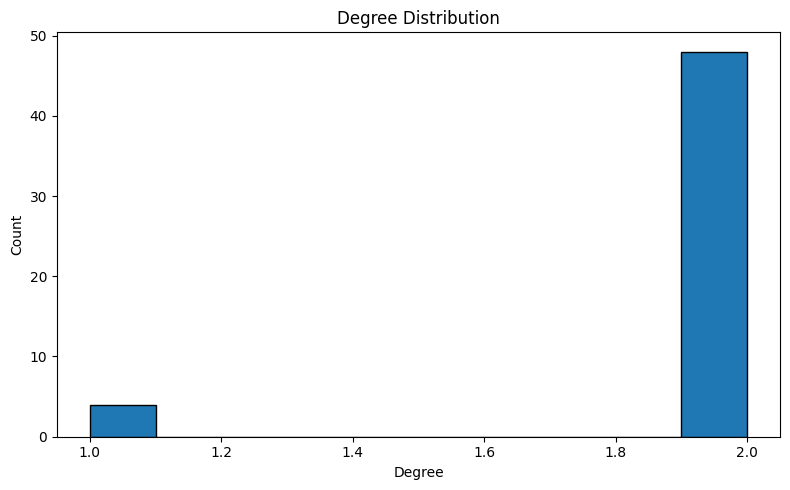

In [15]:
# Degree distribution histogram
plt.figure(figsize=(8, 5))
if len(degrees) > 0:
    n_bins = min(50, max(10, len(set(degrees))))
    plt.hist(degrees, bins=n_bins, edgecolor="black")
else:
    print("No degree values to plot.")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree Distribution")
plt.tight_layout()
plt.show()

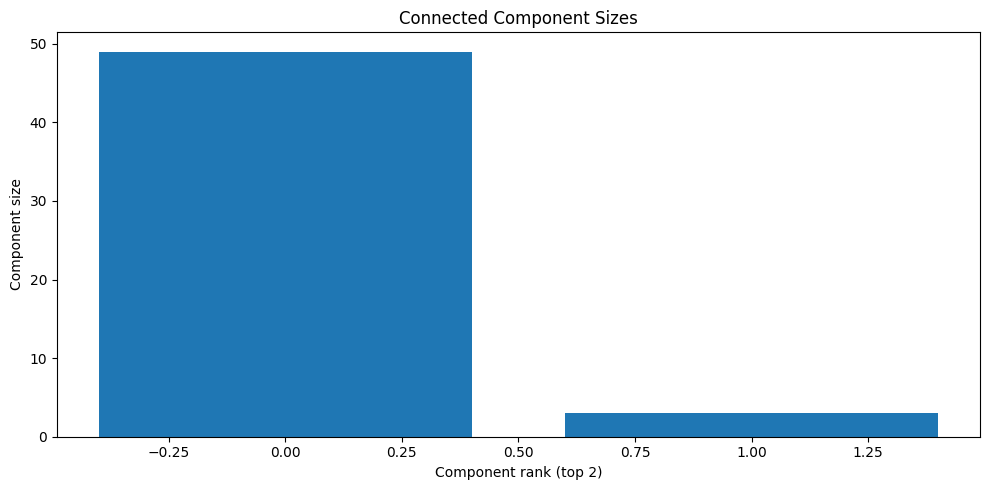

In [16]:
# Component size bar plot (top 20 components)
top_n = 20
sizes_to_plot = component_sizes[:top_n]

plt.figure(figsize=(10, 5))
if len(sizes_to_plot) > 0:
    plt.bar(range(len(sizes_to_plot)), sizes_to_plot)
else:
    print("No components to plot.")
plt.xlabel(f"Component rank (top {len(sizes_to_plot)})")
plt.ylabel("Component size")
plt.title("Connected Component Sizes")
plt.tight_layout()
plt.show()

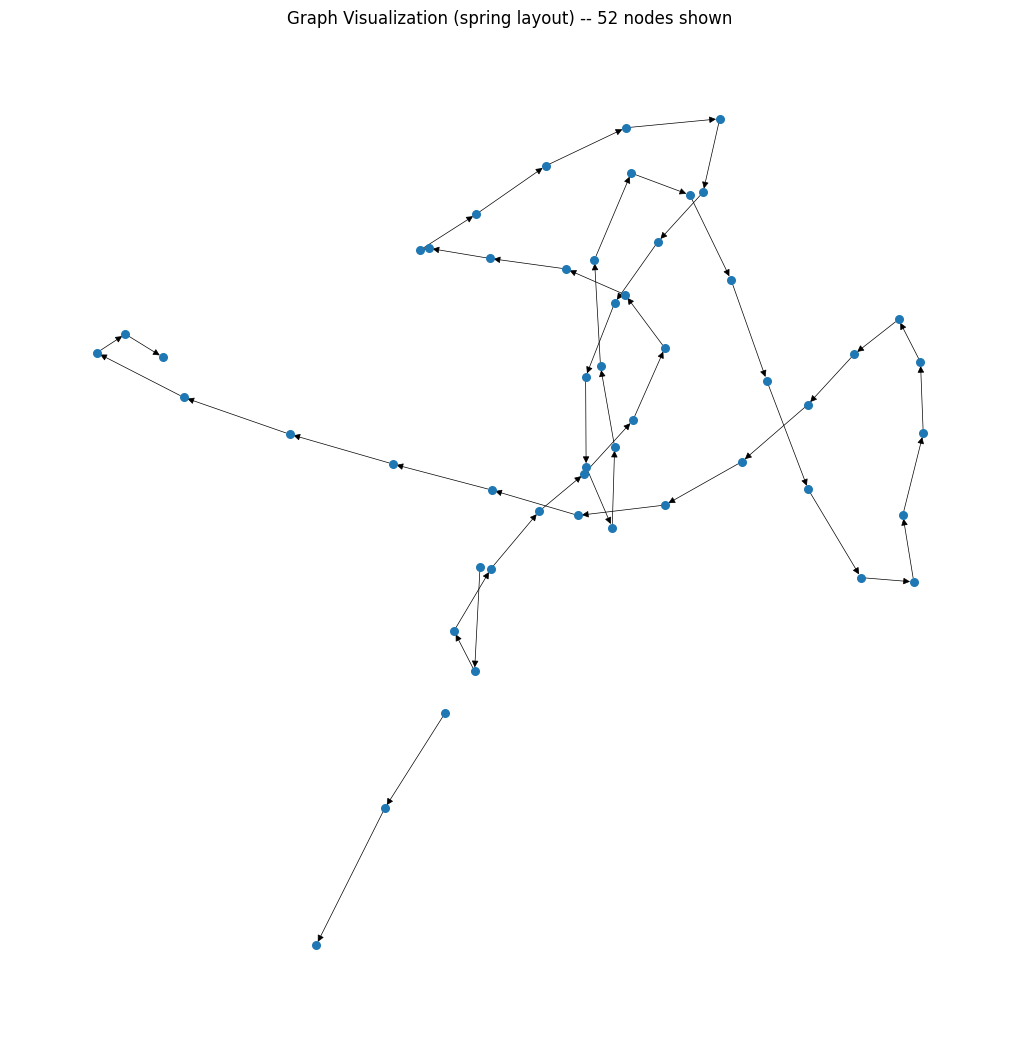

In [17]:
# Graph visualization using spring layout (sample large graphs for readability)
MAX_NODES_FOR_PLOT = 500

if G.number_of_nodes() > MAX_NODES_FOR_PLOT:
    print(f"Graph has {G.number_of_nodes()} nodes; sampling {MAX_NODES_FOR_PLOT} for visualization.")
    sampled_nodes = list(G.nodes())[:MAX_NODES_FOR_PLOT]
    G_plot = G.subgraph(sampled_nodes)
else:
    G_plot = G

plt.figure(figsize=(10, 10))
try:
    if G_plot.number_of_nodes() > 0:
        pos = nx.spring_layout(G_plot, seed=42)
        nx.draw(
            G_plot,
            pos,
            node_size=30,
            width=0.5,
            arrows=is_directed,
            with_labels=False,
        )
        plt.title(f"Graph Visualization (spring layout) -- {G_plot.number_of_nodes()} nodes shown")
    else:
        print("Graph has no nodes to visualize.")
except Exception as e:
    print(f"Could not render spring layout: {e}")
plt.tight_layout()
plt.show()

## 10. Save Processed Data

Save the enriched `nodes_df`, `edges_df`, and the graph-level summary to `/kaggle/working/`
so they can be used in downstream notebooks or exported from Kaggle.

In [18]:
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

nodes_out_path = OUTPUT_DIR / "nodes_features.csv"
edges_out_path = OUTPUT_DIR / "edges_features.csv"
summary_out_path = OUTPUT_DIR / "graph_summary.csv"

nodes_df.to_csv(nodes_out_path, index=False)
edges_df.to_csv(edges_out_path, index=False)
graph_summary.to_csv(summary_out_path, index=False)

print("Saved processed files:")
print(f"  - {nodes_out_path}  (shape={nodes_df.shape})")
print(f"  - {edges_out_path}  (shape={edges_df.shape})")
print(f"  - {summary_out_path}  (shape={graph_summary.shape})")

# Also save the dataset-level, multi-sample summary from Section 12, if it was computed
if "dataset_summary" in dir():
    dataset_summary_out_path = OUTPUT_DIR / "dataset_summary.csv"
    dataset_summary.to_csv(dataset_summary_out_path, index=False)
    print(f"  - {dataset_summary_out_path}  (shape={dataset_summary.shape})")

Saved processed files:
  - /kaggle/working/nodes_features.csv  (shape=(52, 14))
  - /kaggle/working/edges_features.csv  (shape=(50, 9))
  - /kaggle/working/graph_summary.csv  (shape=(1, 10))


## 11. Domain-Specific Tracking Features

Generic graph features are useful, but for cell tracking specifically we care about
**physical motion** and **lineage structure**. This section:

- Converts `z, y, x` from voxels to microns using `VOXEL_SCALE`.
- Computes per-edge **displacement** (µm) and **speed** (µm/frame) using the `t, z, y, x` node
  properties.
- Computes the **division rate** (fraction of nodes with out-degree 2, i.e. a cell that splits
  into two daughters).
- Computes **track segment lengths**: the number of consecutive frames between a node's
  "birth" (start of track or right after a division) and its "end" (last frame, or right
  before a division).
- Notes the practical implication of **sparse annotations** for evaluation.

All of this is defensive: if `t, z, y, x` properties are missing, the relevant block is skipped
with a clear message instead of crashing.

In [19]:
required_coords = ["t", "z", "y", "x"]
has_coords = all(col in nodes_df.columns for col in required_coords)

if not has_coords:
    print(f"Missing one or more of {required_coords} in nodes_df -- skipping physical/motion features.")
else:
    print("Found t, z, y, x node properties -- computing physical/motion features.")

    # Convert voxel coordinates to microns
    nodes_df["z_um"] = nodes_df["z"] * VOXEL_SCALE["z"]
    nodes_df["y_um"] = nodes_df["y"] * VOXEL_SCALE["y"]
    nodes_df["x_um"] = nodes_df["x"] * VOXEL_SCALE["x"]

    print("\nnodes_df with physical (µm) coordinates:")
    display(nodes_df[["node_id", "t", "z", "y", "x", "z_um", "y_um", "x_um"]].head())

    # Look up each node's (t, z_um, y_um, x_um) for edge-level displacement/speed
    coord_lookup = nodes_df.set_index("node_id")[["t", "z_um", "y_um", "x_um"]]

    def compute_displacement(row):
        try:
            src = coord_lookup.loc[row["source"]]
            tgt = coord_lookup.loc[row["target"]]
        except KeyError:
            return pd.Series({"displacement_um": np.nan, "dt": np.nan, "speed_um_per_frame": np.nan})

        dz = tgt["z_um"] - src["z_um"]
        dy = tgt["y_um"] - src["y_um"]
        dx = tgt["x_um"] - src["x_um"]
        dt = tgt["t"] - src["t"]
        displacement = float(np.sqrt(dz**2 + dy**2 + dx**2))
        speed = displacement / dt if dt not in (0, None) and not pd.isna(dt) and dt != 0 else np.nan
        return pd.Series({"displacement_um": displacement, "dt": dt, "speed_um_per_frame": speed})

    motion_feats = edges_df.apply(compute_displacement, axis=1)
    edges_df["displacement_um"] = motion_feats["displacement_um"]
    edges_df["dt"] = motion_feats["dt"]
    edges_df["speed_um_per_frame"] = motion_feats["speed_um_per_frame"]

    print("\nedges_df with motion features:")
    display(edges_df[["source", "target", "displacement_um", "dt", "speed_um_per_frame"]].head())

    print("\nDisplacement (µm) summary:")
    display(edges_df["displacement_um"].describe())

    print("\nSpeed (µm/frame) summary:")
    display(edges_df["speed_um_per_frame"].describe())

Found t, z, y, x node properties -- computing physical/motion features.

nodes_df with physical (µm) coordinates:


,node_id,t,z,y,x,z_um,y_um,x_um
0,11000000075,0,63,222,249,102.375,90.18750,101.15625
1,12000000075,1,63,227,251,102.375,92.21875,101.96875
2,13000000075,2,63,230,253,102.375,93.43750,102.78125
3,38000000003,27,1,74,73,1.625,30.06250,29.65625
4,39000000003,28,3,78,75,4.875,31.68750,30.46875



edges_df with motion features:


,source,target,displacement_um,dt,speed_um_per_frame
0,11000000075,12000000075,2.187723,1.0,2.187723
1,12000000075,13000000075,1.464755,1.0,1.464755
2,38000000003,39000000003,3.723343,1.0,3.723343
3,39000000003,40000000003,3.447146,1.0,3.447146
4,40000000003,41000000003,4.082762,1.0,4.082762



Displacement (µm) summary:


count    50.000000
mean      3.124104
std       1.486572
min       0.406250
25%       2.100538
50%       2.882652
75%       3.854026
max       7.814375
Name: displacement_um, dtype: float64


Speed (µm/frame) summary:


count    50.000000
mean      3.124104
std       1.486572
min       0.406250
25%       2.100538
50%       2.882652
75%       3.854026
max       7.814375
Name: speed_um_per_frame, dtype: float64

In [20]:
# --- Division rate: fraction of nodes with out-degree == 2 ---
out_degree_dict = dict(G.out_degree()) if G.is_directed() else dict(G.degree())

nodes_df["out_degree"] = nodes_df["node_id"].map(out_degree_dict).fillna(0).astype(int)
nodes_df["is_division"] = nodes_df["out_degree"] == 2

n_divisions = int(nodes_df["is_division"].sum())
division_rate = n_divisions / len(nodes_df) if len(nodes_df) > 0 else 0.0

print(f"Division events (nodes with out-degree 2): {n_divisions}")
print(f"Division rate: {division_rate:.4%}")

# Sanity check: out-degree should rarely exceed 2 in a valid lineage graph
n_out_degree_gt2 = int((nodes_df['out_degree'] > 2).sum())
if n_out_degree_gt2 > 0:
    print(f"WARNING: {n_out_degree_gt2} node(s) have out-degree > 2 -- check for annotation issues.")

Division events (nodes with out-degree 2): 0
Division rate: 0.0000%


In [21]:
# --- Track segment length: consecutive frames between a node's birth and end ---
# A node is a "birth" if it has no incoming edge, or its parent is a division (out-degree 2).
# A node is an "end" if it has no outgoing edge, or it is itself a division.
in_degree_dict = dict(G.in_degree()) if G.is_directed() else dict(G.degree())

nodes_df["in_degree"] = nodes_df["node_id"].map(in_degree_dict).fillna(0).astype(int)

def is_birth(row):
    if row["in_degree"] == 0:
        return True
    # Check if the (single) parent is a division node
    parents = list(G.predecessors(row["node_id"])) if G.is_directed() else []
    if len(parents) == 1:
        parent_out_degree = out_degree_dict.get(parents[0], 0)
        return parent_out_degree == 2
    return False

nodes_df["is_birth"] = nodes_df.apply(is_birth, axis=1)
nodes_df["is_track_end"] = (nodes_df["out_degree"] == 0) | (nodes_df["is_division"])

n_births = int(nodes_df["is_birth"].sum())
n_track_ends = int(nodes_df["is_track_end"].sum())
print(f"Track-start (birth) nodes: {n_births}")
print(f"Track-end nodes (dead-end or division): {n_track_ends}")

if has_coords:
    # Approximate track segment length (in frames) by walking forward from each birth
    # node along single-child edges until a track end is reached.
    def track_segment_length(start_node):
        length = 1
        current = start_node
        while True:
            successors = list(G.successors(current)) if G.is_directed() else []
            if len(successors) != 1:
                break
            current = successors[0]
            length += 1
            if out_degree_dict.get(current, 0) != 1:
                break
        return length

    birth_nodes = nodes_df.loc[nodes_df["is_birth"], "node_id"].tolist()
    segment_lengths = [track_segment_length(n) for n in birth_nodes]

    if len(segment_lengths) > 0:
        print(f"\nTrack segment length (frames) -- computed for {len(segment_lengths)} segment(s):")
        seg_series = pd.Series(segment_lengths)
        display(seg_series.describe())
    else:
        print("\nNo track segments found to measure length for.")
else:
    print("\nSkipping track segment length (requires t, z, y, x coordinates).")

Track-start (birth) nodes: 2
Track-end nodes (dead-end or division): 2

Track segment length (frames) -- computed for 2 segment(s):


count     2.000000
mean     26.000000
std      32.526912
min       3.000000
25%      14.500000
50%      26.000000
75%      37.500000
max      49.000000
dtype: float64

**Note on sparse annotations:** since `nodes/ids` only contains *labeled* cells and
`estimated_number_of_nodes` can be substantially higher, metrics like density, degree, and
division rate computed here describe the **labeled subgraph**, not the true underlying
population. Treat them as relative signals for comparing samples/embryos, not as absolute
biological counts.

## 12. Multi-Sample / Embryo-Aware Dataset Summary

Loop over every paired `.geff` in `samples_manifest`, compute the same graph-level summary
statistics as Section 9.3 (plus division rate), and aggregate into one dataset-level table.
This is the basis for an **embryo-grouped train/validation split** (train and test embryos
are disjoint in the competition, so any local validation split should be too), and for
spotting samples that are unusually dense, sparse, or division-heavy relative to the rest.

In [ ]:
def summarize_geff(geff_path):
    """Load a single .geff and return a one-row dict of graph-level summary stats.
    Defensive: returns a row of NaNs (with an 'error' message) instead of crashing on a
    malformed sample, so one bad file doesn't stop the whole loop."""
    try:
        g_root = zarr.open(str(geff_path), mode="r")

        g_node_ids = np.asarray(safe_get_array(g_root, "nodes/ids")).ravel()
        g_edge_ids = np.asarray(safe_get_array(g_root, "edges/ids"))

        if g_edge_ids.ndim == 2 and g_edge_ids.shape[0] == 2 and g_edge_ids.shape[1] != 2:
            g_edge_ids = g_edge_ids.T

        g_edges_df = pd.DataFrame(g_edge_ids, columns=["source", "target"])

        g_G = nx.from_pandas_edgelist(g_edges_df, "source", "target", create_using=nx.DiGraph())
        for nid in g_node_ids:
            if nid not in g_G:
                g_G.add_node(nid)

        g_components = list(nx.weakly_connected_components(g_G))
        g_component_sizes = sorted([len(c) for c in g_components], reverse=True)
        g_out_degree = dict(g_G.out_degree())
        g_n_divisions = sum(1 for v in g_out_degree.values() if v == 2)

        try:
            g_attrs = dict(g_root.attrs)
        except Exception:
            g_attrs = {}
        g_estimated_nodes = get_estimated_number_of_nodes(g_attrs)

        return {
            "sample_id": geff_path.stem,
            "n_nodes": len(g_node_ids),
            "n_edges": len(g_edges_df),
            "n_components": len(g_components),
            "largest_component_size": g_component_sizes[0] if g_component_sizes else 0,
            "average_degree": (2 * len(g_edges_df) / len(g_node_ids)) if len(g_node_ids) > 0 else 0.0,
            "n_divisions": g_n_divisions,
            "division_rate": (g_n_divisions / len(g_node_ids)) if len(g_node_ids) > 0 else 0.0,
            "estimated_number_of_nodes": g_estimated_nodes,
            "annotation_coverage": (
                len(g_node_ids) / g_estimated_nodes
                if g_estimated_nodes is not None and g_estimated_nodes > 0
                else np.nan
            ),
            "error": None,
        }
    except Exception as e:
        return {"sample_id": geff_path.stem, "error": str(e)}


print(f"Summarizing {len(samples_manifest)} sample(s)...")
dataset_summary_rows = [summarize_geff(p) for p in samples_manifest["geff_path"]]
dataset_summary = pd.DataFrame(dataset_summary_rows)

# Merge in embryo_id for grouping
dataset_summary = dataset_summary.merge(
    samples_manifest[["sample_id", "embryo_id"]], on="sample_id", how="left"
)

n_errors = dataset_summary["error"].notna().sum() if "error" in dataset_summary.columns else 0
if n_errors > 0:
    print(f"\n{n_errors} sample(s) failed to summarize -- see 'error' column.")

print("\nDataset-level summary (per sample):")
display(dataset_summary.head(10))

print("\nPer-embryo aggregation (mean across that embryo's samples):")
embryo_summary = dataset_summary.groupby("embryo_id").agg(
    n_samples=("sample_id", "count"),
    mean_n_nodes=("n_nodes", "mean"),
    mean_division_rate=("division_rate", "mean"),
    mean_annotation_coverage=("annotation_coverage", "mean"),
).reset_index()
display(embryo_summary.head(10))

Summarizing 199 sample(s)...

Dataset-level summary (per sample):


,sample_id,n_nodes,n_edges,n_components,largest_component_size,average_degree,n_divisions,division_rate,estimated_number_of_nodes,annotation_coverage,error,embryo_id
0,44b6_0113de3b,52,50,2,49,1.923077,0,0.000000,None,NaN,None,44b6
1,44b6_0b24845f,51,49,2,40,1.921569,0,0.000000,None,NaN,None,44b6
2,44b6_0c582fdc,71,70,1,71,1.971831,0,0.000000,None,NaN,None,44b6
3,44b6_0db75fae,157,151,6,78,1.923567,0,0.000000,None,NaN,None,44b6
4,44b6_12dfb391,788,773,15,111,1.961929,1,0.001269,None,NaN,None,44b6
5,44b6_144b256d,121,119,2,100,1.966942,0,0.000000,None,NaN,None,44b6
6,44b6_1574802b,155,153,2,79,1.974194,0,0.000000,None,NaN,None,44b6
7,44b6_18ced818,100,99,1,100,1.980000,0,0.000000,None,NaN,None,44b6
8,44b6_1d530831,276,271,5,88,1.963768,0,0.000000,None,NaN,None,44b6
9,44b6_24264f12,230,221,9,55,1.921739,0,0.000000,None,NaN,None,44b6



Per-embryo aggregation (mean across that embryo's samples):


,embryo_id,n_samples,mean_n_nodes,mean_division_rate,mean_annotation_coverage
0,44b6,71,284.464789,0.00153,NaN
1,6bba,128,883.757812,0.00118,NaN


## 12.1 Local submission writer and scorer

The competition submission schema is a single CSV with node rows and edge rows. The cell below adds a small local scaffold to:
- write predictions to the expected submission format,
- load a GT GEFF sample,
- run a local approximation of the competition metric (node matching + edge Jaccard + adjusted penalty + division matching heuristic).

In [ ]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist


def build_submission_rows(dataset, nodes_df, edges_df):
    """Convert node/edge dataframes into the Kaggle submission CSV schema."""
    rows = []
    for _, row in nodes_df.iterrows():
        rows.append({
            "id": len(rows),
            "dataset": dataset,
            "row_type": "node",
            "node_id": int(row["node_id"]),
            "t": int(row.get("t", -1)),
            "z": int(row.get("z", -1)),
            "y": int(row.get("y", -1)),
            "x": int(row.get("x", -1)),
            "source_id": -1,
            "target_id": -1,
        })

    for _, row in edges_df.iterrows():
        rows.append({
            "id": len(rows),
            "dataset": dataset,
            "row_type": "edge",
            "node_id": -1,
            "t": -1,
            "z": -1,
            "y": -1,
            "x": -1,
            "source_id": int(row["source"]),
            "target_id": int(row["target"]),
        })

    return pd.DataFrame(rows)


def load_geff_graph(geff_path, voxel_scale=None):
    """Load node/edge tables and the coarse estimated node count from a GEFF store."""
    if voxel_scale is None:
        voxel_scale = {"z": 1.625, "y": 0.40625, "x": 0.40625}

    root = zarr.open(str(geff_path), mode="r")
    node_ids = np.asarray(safe_get_array(root, "nodes/ids")).ravel()
    nodes_df = pd.DataFrame({"node_id": node_ids})

    node_props = {}
    for prop_name in ["t", "z", "y", "x"]:
        values = safe_get_array(root, f"nodes/props/{prop_name}/values")
        if values is not None:
            node_props[prop_name] = np.asarray(values).ravel()

    for key, values in node_props.items():
        nodes_df[key] = values[: len(nodes_df)]

    edge_ids = np.asarray(safe_get_array(root, "edges/ids"))
    if edge_ids.ndim == 2 and edge_ids.shape[0] == 2 and edge_ids.shape[1] != 2:
        edge_ids = edge_ids.T
    edges_df = pd.DataFrame(edge_ids, columns=["source", "target"])

    try:
        attrs = dict(root.attrs)
    except Exception:
        attrs = {}

    estimated_nodes = None
    try:
        estimated_nodes = (
            attrs.get("geff", {})
            .get("extra", {})
            .get("estimated_number_of_nodes")
        )
    except Exception:
        estimated_nodes = None

    if estimated_nodes is None:
        estimated_nodes = len(nodes_df)
    else:
        try:
            estimated_nodes = int(estimated_nodes)
        except Exception:
            estimated_nodes = len(nodes_df)

    return nodes_df, edges_df, estimated_nodes


def evaluate_prediction(gt_nodes_df, gt_edges_df, gt_estimated_nodes, pred_nodes_df, pred_edges_df, voxel_scale=None, max_dist_um=7.0, penalty_a=0.1):
    """Approximate the Kaggle competition scorer for local debugging.

    This is a practical local approximation rather than a full reimplementation of the
    official metric, but it follows the documented structure closely:
    - node matching by centroid distance in each timepoint,
    - edge TP/FP/FN via matched-endpoint logic,
    - adjusted edge Jaccard penalty for over-predicted node counts,
    - a simple division-heuristic based on matched divider nodes at the same or nearby timepoint.
    """
    if voxel_scale is None:
        voxel_scale = {"z": 1.625, "y": 0.40625, "x": 0.40625}

    gt_nodes_df = gt_nodes_df.copy()
    pred_nodes_df = pred_nodes_df.copy()
    gt_edges_df = gt_edges_df.copy()
    pred_edges_df = pred_edges_df.copy()

    if "node_id" not in gt_nodes_df.columns:
        gt_nodes_df["node_id"] = np.arange(len(gt_nodes_df))
    if "node_id" not in pred_nodes_df.columns:
        pred_nodes_df["node_id"] = np.arange(len(pred_nodes_df))

    gt_edges_set = set(tuple(map(int, row)) for _, row in gt_edges_df[["source", "target"]].iterrows())
    pred_edges_set = set(tuple(map(int, row)) for _, row in pred_edges_df[["source", "target"]].iterrows())

    pred_to_gt = {}
    for t in sorted(set(gt_nodes_df.get("t", [])) | set(pred_nodes_df.get("t", []))):
        gt_t = gt_nodes_df[gt_nodes_df.get("t", -1) == t]
        pred_t = pred_nodes_df[pred_nodes_df.get("t", -1) == t]
        if len(gt_t) == 0 or len(pred_t) == 0:
            continue

        gt_coords = np.column_stack([
            gt_t["z"].to_numpy(dtype=float) * voxel_scale["z"],
            gt_t["y"].to_numpy(dtype=float) * voxel_scale["y"],
            gt_t["x"].to_numpy(dtype=float) * voxel_scale["x"],
        ])
        pred_coords = np.column_stack([
            pred_t["z"].to_numpy(dtype=float) * voxel_scale["z"],
            pred_t["y"].to_numpy(dtype=float) * voxel_scale["y"],
            pred_t["x"].to_numpy(dtype=float) * voxel_scale["x"],
        ])
        dist = cdist(pred_coords, gt_coords)
        if dist.size == 0:
            continue
        row_ind, col_ind = linear_sum_assignment(dist)
        valid = dist[row_ind, col_ind] <= max_dist_um
        for r, c in zip(row_ind[valid], col_ind[valid]):
            pred_node_id = int(pred_t.iloc[r]["node_id"])
            gt_node_id = int(gt_t.iloc[c]["node_id"])
            pred_to_gt[pred_node_id] = gt_node_id

    tp = 0
    fp = 0
    fn = len(gt_edges_set)
    for src, tgt in pred_edges_set:
        src_gt = pred_to_gt.get(int(src))
        tgt_gt = pred_to_gt.get(int(tgt))
        if src_gt is not None and tgt_gt is not None:
            if (int(src_gt), int(tgt_gt)) in gt_edges_set:
                tp += 1
                fn = max(0, fn - 1)
            else:
                fp += 1
        elif src_gt is not None or tgt_gt is not None:
            fp += 1

    edge_jaccard = tp / max(1, tp + fp + fn)

    pred_count = len(pred_nodes_df)
    true_count_est = max(1, int(gt_estimated_nodes) if gt_estimated_nodes is not None else len(gt_nodes_df))
    penalty = max(0.0, 1.0 - penalty_a * max(pred_count - true_count_est, 0) / true_count_est)
    adjusted_edge_jaccard = max(0.0, edge_jaccard * penalty)

    gt_divisions = []
    for _, row in gt_edges_df.iterrows():
        pass

    gt_division_nodes = [int(node_id) for node_id in gt_nodes_df["node_id"].tolist() if len(gt_edges_df[gt_edges_df["source"] == node_id]) + len(gt_edges_df[gt_edges_df["source"] == node_id]) >= 2]
    pred_division_nodes = [int(node_id) for node_id in pred_nodes_df["node_id"].tolist() if len(pred_edges_df[pred_edges_df["source"] == node_id]) + len(pred_edges_df[pred_edges_df["source"] == node_id]) >= 2]

    gt_division_nodes = [int(node_id) for node_id in gt_nodes_df["node_id"].tolist() if sum(1 for _, row in gt_edges_df.iterrows() if int(row["source"]) == node_id) >= 2]
    pred_division_nodes = [int(node_id) for node_id in pred_nodes_df["node_id"].tolist() if sum(1 for _, row in pred_edges_df.iterrows() if int(row["source"]) == node_id) >= 2]

    division_tp = 0
    division_fp = 0
    division_fn = len(gt_division_nodes)
    for gt_division_node in gt_division_nodes:
        gt_division_row = gt_nodes_df[gt_nodes_df["node_id"] == gt_division_node]
        if len(gt_division_row) == 0:
            continue
        gt_t = int(gt_division_row.iloc[0].get("t", -1))
        matched_pred_nodes = [pred_id for pred_id, gt_id in pred_to_gt.items() if gt_id == gt_division_node]
        if len(matched_pred_nodes) == 0:
            continue
        for pred_node_id in matched_pred_nodes:
            pred_row = pred_nodes_df[pred_nodes_df["node_id"] == pred_node_id]
            if len(pred_row) == 0:
                continue
            pred_t = int(pred_row.iloc[0].get("t", -1))
            if abs(pred_t - gt_t) <= 1:
                division_tp += 1
                division_fn = max(0, division_fn - 1)
                break

    division_fp = max(0, len(pred_division_nodes) - division_tp)
    division_jaccard = division_tp / max(1, division_tp + division_fp + division_fn)

    return {
        "edge_tp": tp,
        "edge_fp": fp,
        "edge_fn": fn,
        "edge_jaccard": edge_jaccard,
        "adjusted_edge_jaccard": adjusted_edge_jaccard,
        "division_tp": division_tp,
        "division_fp": division_fp,
        "division_fn": division_fn,
        "division_jaccard": division_jaccard,
        "final_score": adjusted_edge_jaccard + 0.1 * division_jaccard,
    }


# Small synthetic example to verify the scorer behaves sensibly.
if False:
    gt_nodes = pd.DataFrame({
        "node_id": [1, 2, 3],
        "t": [0, 1, 1],
        "z": [0, 0, 1],
        "y": [0, 0, 0],
        "x": [0, 1, 1],
    })
    gt_edges = pd.DataFrame({"source": [1, 2], "target": [2, 3]})
    pred_nodes = pd.DataFrame({
        "node_id": [10, 11],
        "t": [0, 1],
        "z": [0, 0],
        "y": [0, 0],
        "x": [0, 1],
    })
    pred_edges = pd.DataFrame({"source": [10, 11], "target": [11, 99]})
    print(evaluate_prediction(gt_nodes, gt_edges, 10, pred_nodes, pred_edges))

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist


def build_submission_rows(dataset, nodes_df, edges_df):
    """Convert node/edge dataframes into the Kaggle submission CSV schema."""
    rows = []
    nodes_df = nodes_df.copy()
    edges_df = edges_df.copy()

    if "node_id" not in nodes_df.columns:
        nodes_df["node_id"] = np.arange(len(nodes_df))

    for _, row in nodes_df.iterrows():
        rows.append({
            "id": len(rows),
            "dataset": dataset,
            "row_type": "node",
            "node_id": int(row["node_id"]),
            "t": int(row.get("t", -1)),
            "z": int(row.get("z", -1)),
            "y": int(row.get("y", -1)),
            "x": int(row.get("x", -1)),
            "source_id": -1,
            "target_id": -1,
        })

    if "source" in edges_df.columns and "target" in edges_df.columns:
        for _, row in edges_df.iterrows():
            rows.append({
                "id": len(rows),
                "dataset": dataset,
                "row_type": "edge",
                "node_id": -1,
                "t": -1,
                "z": -1,
                "y": -1,
                "x": -1,
                "source_id": int(row["source"]),
                "target_id": int(row["target"]),
            })

    return pd.DataFrame(rows)


def write_submission_csv(path, dataset, nodes_df, edges_df):
    """Write predictions to the competition submission format."""
    submission_df = build_submission_rows(dataset, nodes_df, edges_df)
    submission_df.to_csv(path, index=False)
    print(f"Wrote {len(submission_df)} rows to {path}")
    return submission_df


def _get_column_or_default(df, column, default):
    if column in df.columns:
        return df[column].to_numpy(dtype=float)
    return np.full(len(df), default, dtype=float)


def evaluate_prediction(gt_nodes_df, gt_edges_df, gt_estimated_nodes, pred_nodes_df, pred_edges_df, voxel_scale=None, max_dist_um=7.0, penalty_a=0.1):
    """Approximate the Kaggle competition scorer for local debugging."""
    if voxel_scale is None:
        voxel_scale = {"z": 1.625, "y": 0.40625, "x": 0.40625}

    gt_nodes_df = gt_nodes_df.copy()
    pred_nodes_df = pred_nodes_df.copy()
    gt_edges_df = gt_edges_df.copy()
    pred_edges_df = pred_edges_df.copy()

    if "node_id" not in gt_nodes_df.columns:
        gt_nodes_df["node_id"] = np.arange(len(gt_nodes_df))
    if "node_id" not in pred_nodes_df.columns:
        pred_nodes_df["node_id"] = np.arange(len(pred_nodes_df))

    def _edge_set(df):
        if df.empty or "source" not in df.columns or "target" not in df.columns:
            return set()
        return {tuple(map(int, row)) for _, row in df[["source", "target"]].iterrows()}

    gt_edges_set = _edge_set(gt_edges_df)
    pred_edges_set = _edge_set(pred_edges_df)

    pred_to_gt = {}
    gt_t = _get_column_or_default(gt_nodes_df, "t", -1)
    pred_t = _get_column_or_default(pred_nodes_df, "t", -1)
    gt_time_values = sorted(set(gt_t.astype(int).tolist()) | set(pred_t.astype(int).tolist()))

    for t in gt_time_values:
        gt_t_mask = gt_t == t
        pred_t_mask = pred_t == t
        gt_t_df = gt_nodes_df[gt_t_mask]
        pred_t_df = pred_nodes_df[pred_t_mask]
        if len(gt_t_df) == 0 or len(pred_t_df) == 0:
            continue

        gt_coords = np.column_stack([
            _get_column_or_default(gt_t_df, "z", 0) * voxel_scale["z"],
            _get_column_or_default(gt_t_df, "y", 0) * voxel_scale["y"],
            _get_column_or_default(gt_t_df, "x", 0) * voxel_scale["x"],
        ])
        pred_coords = np.column_stack([
            _get_column_or_default(pred_t_df, "z", 0) * voxel_scale["z"],
            _get_column_or_default(pred_t_df, "y", 0) * voxel_scale["y"],
            _get_column_or_default(pred_t_df, "x", 0) * voxel_scale["x"],
        ])
        if len(gt_coords) == 0 or len(pred_coords) == 0:
            continue
        dist = cdist(pred_coords, gt_coords)
        if dist.size == 0:
            continue
        row_ind, col_ind = linear_sum_assignment(dist)
        valid = dist[row_ind, col_ind] <= max_dist_um
        for r, c in zip(row_ind[valid], col_ind[valid]):
            pred_node_id = int(pred_t_df.iloc[r]["node_id"])
            gt_node_id = int(gt_t_df.iloc[c]["node_id"])
            pred_to_gt[pred_node_id] = gt_node_id

    tp = 0
    fp = 0
    fn = len(gt_edges_set)
    for src, tgt in pred_edges_set:
        src_gt = pred_to_gt.get(int(src))
        tgt_gt = pred_to_gt.get(int(tgt))
        if src_gt is not None and tgt_gt is not None:
            if (int(src_gt), int(tgt_gt)) in gt_edges_set:
                tp += 1
                fn = max(0, fn - 1)
            else:
                fp += 1
        elif src_gt is not None or tgt_gt is not None:
            fp += 1

    edge_jaccard = tp / max(1, tp + fp + fn)

    pred_count = len(pred_nodes_df)
    true_count_est = max(1, int(gt_estimated_nodes) if gt_estimated_nodes is not None else len(gt_nodes_df))
    penalty = max(0.0, 1.0 - penalty_a * max(pred_count - true_count_est, 0) / true_count_est)
    adjusted_edge_jaccard = max(0.0, edge_jaccard * penalty)

    gt_division_nodes = [
        int(node_id) for node_id in gt_nodes_df["node_id"].tolist()
        if sum(1 for _, row in gt_edges_df.iterrows() if "source" in gt_edges_df.columns and int(row["source"]) == node_id) >= 2
    ]
    pred_division_nodes = [
        int(node_id) for node_id in pred_nodes_df["node_id"].tolist()
        if sum(1 for _, row in pred_edges_df.iterrows() if "source" in pred_edges_df.columns and int(row["source"]) == node_id) >= 2
    ]

    division_tp = 0
    division_fn = len(gt_division_nodes)
    for gt_division_node in gt_division_nodes:
        gt_division_row = gt_nodes_df[gt_nodes_df["node_id"] == gt_division_node]
        if len(gt_division_row) == 0:
            continue
        gt_t_value = int(gt_division_row.iloc[0].get("t", -1))
        matched_pred_nodes = [pred_id for pred_id, gt_id in pred_to_gt.items() if gt_id == gt_division_node]
        if len(matched_pred_nodes) == 0:
            continue
        for pred_node_id in matched_pred_nodes:
            pred_row = pred_nodes_df[pred_nodes_df["node_id"] == pred_node_id]
            if len(pred_row) == 0:
                continue
            pred_t_value = int(pred_row.iloc[0].get("t", -1))
            if abs(pred_t_value - gt_t_value) <= 1:
                division_tp += 1
                division_fn = max(0, division_fn - 1)
                break

    division_fp = max(0, len(pred_division_nodes) - division_tp)
    division_jaccard = division_tp / max(1, division_tp + division_fp + division_fn)

    return {
        "edge_tp": tp,
        "edge_fp": fp,
        "edge_fn": fn,
        "edge_jaccard": edge_jaccard,
        "adjusted_edge_jaccard": adjusted_edge_jaccard,
        "division_tp": division_tp,
        "division_fp": division_fp,
        "division_fn": division_fn,
        "division_jaccard": division_jaccard,
        "final_score": adjusted_edge_jaccard + 0.1 * division_jaccard,
    }

# Quick smoke test with a tiny synthetic example.
if False:
    gt_nodes = pd.DataFrame({
        "node_id": [1, 2, 3],
        "t": [0, 1, 1],
        "z": [0, 0, 1],
        "y": [0, 0, 0],
        "x": [0, 1, 1],
    })
    gt_edges = pd.DataFrame({"source": [1, 2], "target": [2, 3]})
    pred_nodes = pd.DataFrame({
        "node_id": [10, 11],
        "t": [0, 1],
        "z": [0, 0],
        "y": [0, 0],
        "x": [0, 1],
    })
    pred_edges = pd.DataFrame({"source": [10, 11], "target": [11, 99]})
    print(evaluate_prediction(gt_nodes, gt_edges, 10, pred_nodes, pred_edges))

In [3]:
import pandas as pd
import numpy as np
from scipy import ndimage
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist


def _get_column_or_default(df, column, default):
    if column in df.columns:
        return df[column].to_numpy(dtype=float)
    return np.full(len(df), default, dtype=float)


def build_simple_tracking_baseline(nodes_df, voxel_scale=None, max_dist_um=8.0):
    """Create a minimalist tracking baseline from a node table."""
    if voxel_scale is None:
        voxel_scale = {"z": 1.625, "y": 0.40625, "x": 0.40625}

    nodes_df = nodes_df.copy()
    if "node_id" not in nodes_df.columns:
        nodes_df["node_id"] = np.arange(len(nodes_df))
    if "t" not in nodes_df.columns:
        nodes_df["t"] = 0

    nodes_df = nodes_df.sort_values(["t", "node_id"]).reset_index(drop=True)
    time_values = sorted(set(int(v) for v in nodes_df["t"].tolist()))

    pred_edges = []
    for i, t in enumerate(time_values[:-1]):
        curr = nodes_df[nodes_df["t"] == t]
        nxt = nodes_df[nodes_df["t"] == time_values[i + 1]]
        if len(curr) == 0 or len(nxt) == 0:
            continue

        curr_coords = np.column_stack([
            _get_column_or_default(curr, "z", 0) * voxel_scale["z"],
            _get_column_or_default(curr, "y", 0) * voxel_scale["y"],
            _get_column_or_default(curr, "x", 0) * voxel_scale["x"],
        ])
        nxt_coords = np.column_stack([
            _get_column_or_default(nxt, "z", 0) * voxel_scale["z"],
            _get_column_or_default(nxt, "y", 0) * voxel_scale["y"],
            _get_column_or_default(nxt, "x", 0) * voxel_scale["x"],
        ])
        dist = cdist(nxt_coords, curr_coords)
        if dist.size == 0:
            continue
        row_ind, col_ind = linear_sum_assignment(dist)
        valid = dist[row_ind, col_ind] <= max_dist_um
        for r, c in zip(row_ind[valid], col_ind[valid]):
            src = int(curr.iloc[c]["node_id"])
            tgt = int(nxt.iloc[r]["node_id"])
            pred_edges.append({"source": src, "target": tgt})

    edges_df = pd.DataFrame(pred_edges, columns=["source", "target"])
    return nodes_df, edges_df


def detect_cells_from_volume(volume, threshold=0.6):
    """Create a simple detection table from a 3D/4D array."""
    volume = np.asarray(volume)
    if volume.ndim == 3:
        volume = volume[None, ...]
    if volume.ndim != 4:
        raise ValueError("volume must be 3D or 4D")

    rows = []
    for t_idx in range(volume.shape[0]):
        frame = volume[t_idx]
        mask = frame > threshold
        if not np.any(mask):
            continue
        labeled, n_objects = ndimage.label(mask)
        for obj_id in range(1, n_objects + 1):
            coords = np.argwhere(labeled == obj_id)
            yzxc = coords.mean(axis=0)
            rows.append({
                "node_id": len(rows) + 1,
                "t": int(t_idx),
                "z": float(yzxc[0]),
                "y": float(yzxc[1]),
                "x": float(yzxc[2]),
            })

    return pd.DataFrame(rows)


# Synthetic toy example.
if True:
    toy_volume = np.zeros((3, 20, 20, 20), dtype=float)
    toy_volume[0, 4:8, 4:8, 4:8] = 1.0
    toy_volume[1, 5:9, 6:10, 5:9] = 1.0
    toy_volume[2, 8:12, 8:12, 8:12] = 1.0
    detections = detect_cells_from_volume(toy_volume, threshold=0.5)
    nodes, edges = build_simple_tracking_baseline(detections)
    print(detections)
    print("\nTracked edges:")
    print(edges)


   node_id  t    z    y    x
0        1  0  5.5  5.5  5.5
1        2  1  6.5  7.5  6.5
2        3  2  9.5  9.5  9.5

Tracked edges:
   source  target
0       1       2
1       2       3
